In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi

In [29]:
def img_area(binary_img):
    area = np.count_nonzero(binary_img)
    return area

In [30]:
def img_perimeter(border_img):
    perimeter = np.count_nonzero(border_img)
    return perimeter

In [31]:
def find_max_d(binary_img):
    min_x=min_y=1e9
    max_x=max_y=0
    h,w=binary_img.shape
    for x in range(h):
        for y in range(w):
            if(binary_img[x,y]<=0):
                continue
            min_x=min(min_x,x)
            min_y=min(min_y,y)
            max_x=max(max_x,x)
            max_y=max(max_y,y)
    
    return (max_x-min_x,max_y-min_y)

In [32]:
def calc_descriptors(binary_img,i):
    _,binary_img = cv2.threshold(binary_img, 127, 255, cv2.THRESH_BINARY)

    kernel = np.ones((3,1),np.uint8)
    eroded = cv2.erode(binary_img,kernel,iterations = 1)
    border_img=binary_img-eroded

    # cv2.imshow(f'border_{i}',border_img)
    # cv2.imshow(f'binary_{i}',binary_img)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    
    area=img_area(binary_img)
    perimeter=img_perimeter(border_img)
    
    max_d_tup=find_max_d(binary_img)
    max_d=max(max_d_tup)

    compactness=(perimeter**2)/area
    form_factor=(4*pi*area)/(perimeter**2)
    roundness=(4*area)/(pi*max_d**2)

    return compactness,form_factor,roundness

In [33]:
def find_euc_dist(t1, t2):
    abs_c = (t1[0] - t2[0])**2
    abs_f = (t1[1] - t2[1])**2
    abs_r = (t1[2] - t2[2])**2
    
    return sqrt( abs_c + abs_f + abs_r )

In [34]:
# Cosine Similarity
def find_cos_sim(t1,t2):

    dot_product=0
    for i in range(len(t1)):
        dot_product+=t1[i]*t2[i]
    
    mag1=0
    for i in range(len(t1)):
        mag1+=t1[i]*t1[i]
    mag1=sqrt(mag1)
    
    mag2=0
    for i in range(len(t2)):
        mag2+=t2[i]*t2[i]
    mag2 = sqrt(mag2)
    
    if mag1==0 or mag2==0:
        return 0
    
    similarity=dot_product/(mag1*mag2)
    return similarity

In [35]:
def similarity_matrix_with_images(train_images, test_images):
    train_descriptors = []
    test_descriptors = []

    for i, img in enumerate(train_images):
        comp, form, round = calc_descriptors(img, i)
        train_descriptors.append((comp, form, round))
    
    for i, img in enumerate(test_images):
        comp, form, round = calc_descriptors(img, i)
        test_descriptors.append((comp, form, round))
    
    sim_matrix = []
    for i, test_d in enumerate(test_descriptors):
        sim_row = []
        for j, train_d in enumerate(train_descriptors):
            cos_sim = find_cos_sim(test_d, train_d)
            # euc_dist = find_euc_dist(test_d, train_d)
            sim_row.append(cos_sim)
        sim_matrix.append(sim_row)
    
    # print("train", train_descriptors)
    # print("test", test_descriptors)
    # print("sim", sim_matrix)
    
    # Create figure with subplots
    plt.figure(figsize=(15, 10))
    
    # Create grid layout
    rows = len(test_images) + 1  # +1 for header row
    cols = len(train_images) + 1  # +1 for test images column
    
    # Top row: Train images
    for j, train_img in enumerate(train_images):
        plt.subplot(rows, cols, j + 2)  # Skip first cell
        plt.imshow(train_img, cmap='gray')
        plt.title(f'GT{j+1}')
        plt.axis('off')
    
    # Left column: Test images and similarity values
    for i in range(len(test_images)):
        # Test image in rightmost column
        plt.subplot(rows, cols, (i + 1) * cols + 1)
        plt.imshow(test_images[i], cmap='gray')
        plt.title(f'Test {i+1}')
        plt.axis('off')
        
        # Similarity values
        for j in range(len(train_images)):
            plt.subplot(rows, cols, (i + 1) * cols + j + 2)
            similarity_val = sim_matrix[i][j]
            plt.text(0.5, 0.5, f'{similarity_val:.5f}')
            plt.axis('off')
            
    
    plt.suptitle('Similarity Matrix')
    plt.tight_layout()
    plt.show()
    
    return sim_matrix


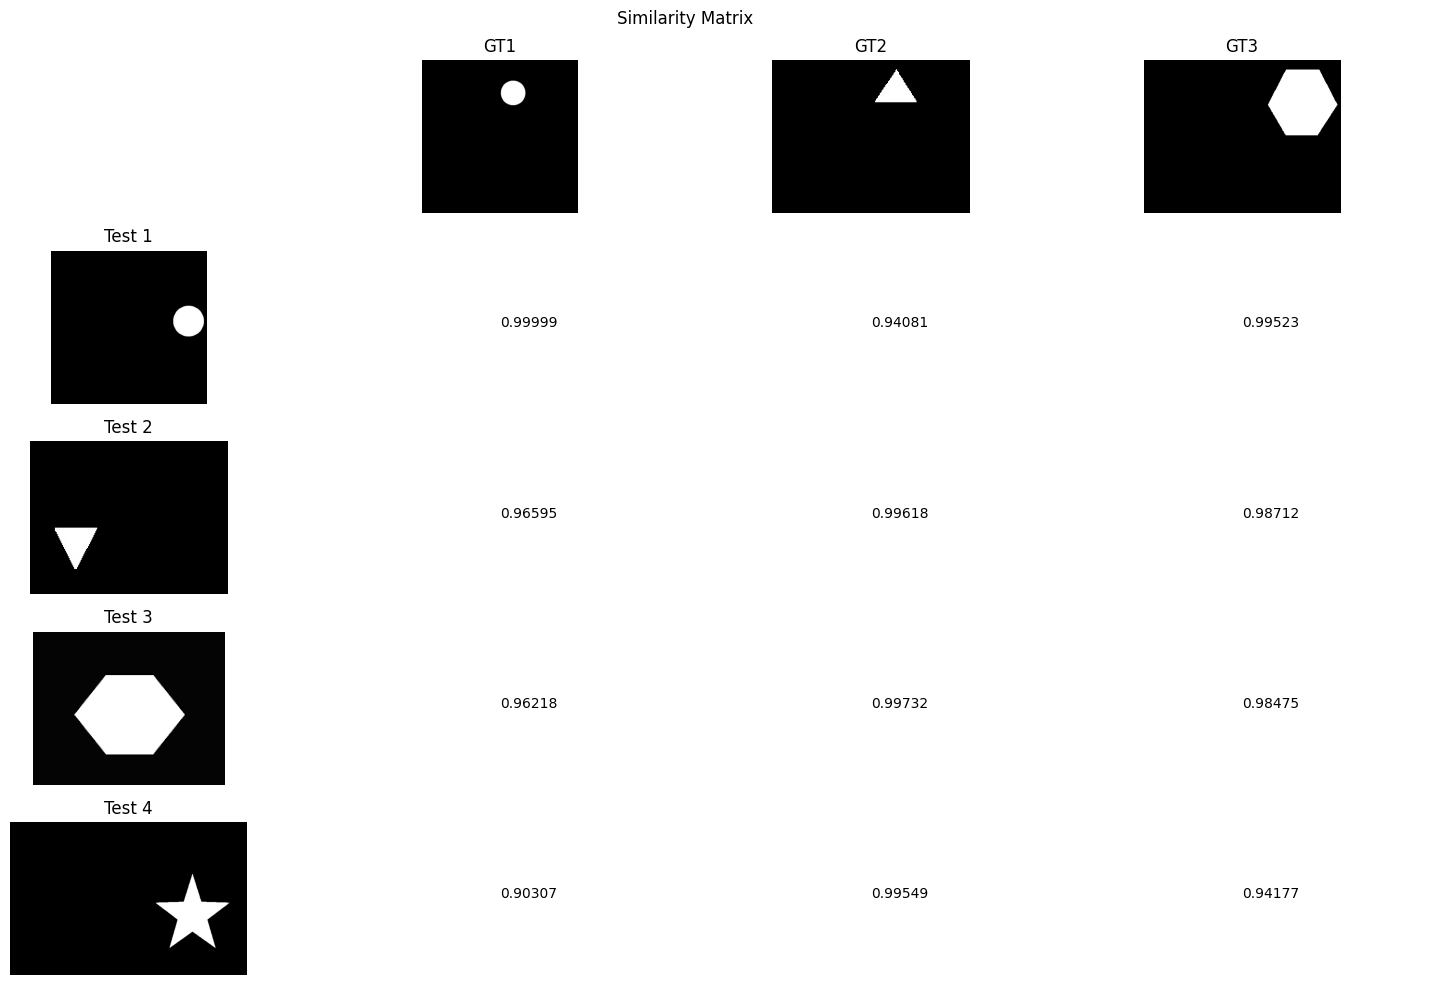

In [36]:
train_images=[
    cv2.imread('./test_assets/c1.jpg',0),
    cv2.imread('./test_assets/t1.jpg',0),
    cv2.imread('./test_assets/p1.png',0)
]

test_images=[
    cv2.imread('./test_assets/c2.jpg',0),
    cv2.imread('./test_assets/t2.jpg',0),
    cv2.imread('./test_assets/p2.png',0),
    cv2.imread('./test_assets/st.jpg',0),
]
#  Call the function
result = similarity_matrix_with_images(train_images, test_images)